#1. Анализ двухмерного массива NumPy

Задача: Дан двумерный массив чисел. Необходимо найти сумму всех четных чисел в каждом ряду (строке), затем вывести ряд с максимальной суммой четных значений.


**Мое решение**

In [3]:
import numpy as np

matrix = np.random.randint(1, 100, size=(5, 5))

# Ваш код здесь
print(matrix)
# Для каждой строки: берём только чётные элементы и суммируем их
# Условие matrix % 2 == 0 даёт маску, где True для чётных.
# Затем умножаем матрицу на маску (чётные остаются, нечётные становятся 0) и суммируем по строкам.
row_sums = np.sum(matrix * (matrix % 2 == 0), axis=1)
# Индекс строки с максимальной суммой
max_row_idx = np.argmax(row_sums)

print("\nСуммы чётных чисел по строкам:", row_sums)
print(f'Максимальная сумма четных чисел находится в строке {max_row_idx}')
print(matrix[max_row_idx])
print(f"Максимальная сумма: {row_sums[max_row_idx]}")

[[66  8 75 80 42]
 [13  7 14 34 40]
 [62 79 36 71 93]
 [95 53  5 78 19]
 [39 51 68 33 25]]

Суммы чётных чисел по строкам: [196  88  98  78  68]
Максимальная сумма четных чисел находится в строке 0
[66  8 75 80 42]
Максимальная сумма: 196


Решение

In [ ]:
import numpy as np

# Создаем случайную матрицу размером 5x5
matrix = np.random.randint(1, 100, size=(5, 5))

# Вычисляем суммы четных строк двумя частями:
#   1. Суммы всех элементов в четных колонках
#   2. Суммы четных элементов в нечетных колонках
even_col_sums = matrix[:, ::2].sum(axis=1)
odd_col_even_elements_sums = matrix[:, 1::2] % 2 == 0  # Булевские маски четных элементов
odd_col_even_elements_sums = np.where(odd_col_even_elements_sums, matrix[:, 1::2], 0).sum(axis=1)

# Полная сумма по каждому ряду
total_sums_per_row = even_col_sums + odd_col_even_elements_sums

# Индекс строки с максимальной суммой
max_row_idx = total_sums_per_row.argmax()

# Печать результата
print(f'Максимальная сумма четных чисел находится в строке {max_row_idx}')

Максимальная сумма четных чисел находится в строке 4


------------------------------------------------------

#2. Обработка отсутствующих данных в DataFrame (Pandas)

Задача: Дана таблица с пропущенными значениями (NaN), заполните пропуски средним значением соответствующего столбца.

In [18]:
import pandas as pd
import numpy as np

data = {
    'A': [1, 2, np.nan],
    'B': [np.nan, 4, 5],
    'C': [6, 7, 8]
}

df = pd.DataFrame(data)

df = pd.DataFrame(data)
df_filled = df.fillna(df.mean())
print(df_filled)

     A    B  C
0  1.0  4.5  6
1  2.0  4.0  7
2  1.5  5.0  8


Решение:

In [17]:
import pandas as pd
import numpy as np

data = {
    'A': [1, 2, np.nan],
    'B': [np.nan, 4, 5],
    'C': [6, 7, 8]
}

df = pd.DataFrame(data)

df_filled = df.fillna(df.mean())

print(df_filled)

     A    B  C
0  1.0  4.5  6
1  2.0  4.0  7
2  1.5  5.0  8


---------------------------------------------------------------

#3. Группировка и агрегация данных (Pandas)

Задача: Есть список покупок разных клиентов с разными товарами и ценами. Найдите среднюю цену каждого товара по категориям товаров.

In [27]:
import pandas as pd

data = {
    'customer_id': ['Alice', 'Bob', 'Charlie', 'Alice'],
    'product_category': ['Electronics', 'Clothing', 'Books', 'Electronics'],
    'price': [100, 50, 20, 150]
}

df = pd.DataFrame(data)

# Ваш код здесь

grouped_data = df.groupby('product_category').agg({'price': 'mean'}).sort_values('price', ascending=False)


print(grouped_data)

                  price
product_category       
Electronics       125.0
Clothing           50.0
Books              20.0


Решение:

In [ ]:
import pandas as pd

data = {
    'customer_id': ['Alice', 'Bob', 'Charlie', 'Alice'],
    'product_category': ['Electronics', 'Clothing', 'Books', 'Electronics'],
    'price': [100, 50, 20, 150]
}

df = pd.DataFrame(data)

grouped_data = df.groupby('product_category').agg({'price': 'mean'})

print(grouped_data)

                  price
product_category       
Books              20.0
Clothing           50.0
Electronics       125.0


-------------------------------------------------------------------

#4. Математические операции над многомерными массивами (NumPy)

Задача: Реализовать свертку (convolution) одномерного сигнала с ядром (kernel).

Дан сигнал длиной N и ядро K длины M (например, фильтр Гаусса):

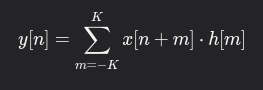

где x — входной сигнал, h — ядро фильтра, y — выходная последовательность.

Реализуйте операцию вручную без встроенных функций вроде convolve() или аналогичных методов.

In [ ]:
import numpy as np

signal = np.array([1, 2, 3, 4, 5])
kernel = np.array([0.25, 0.5, 0.25])  # пример ядра

# Ваш код здесь

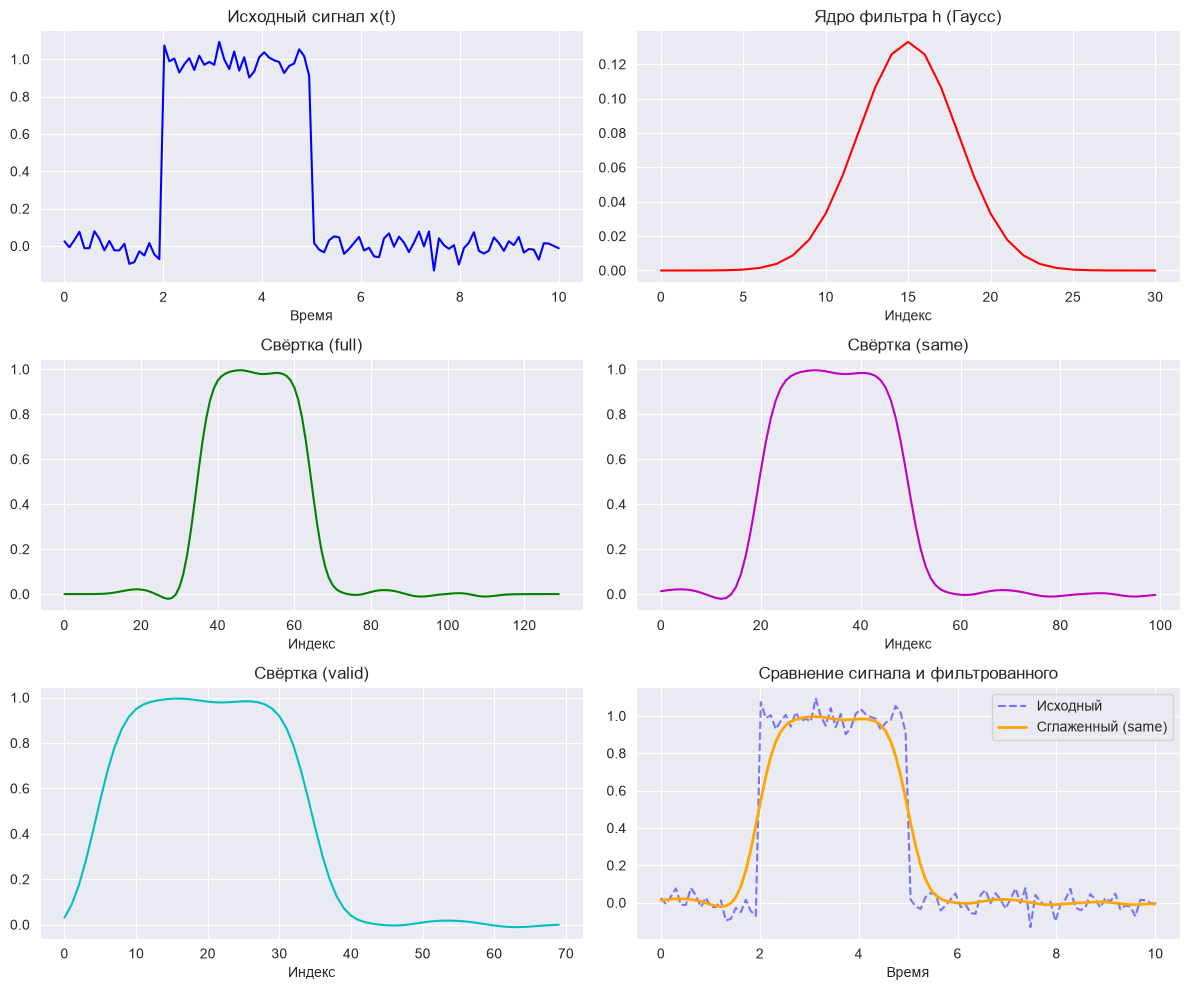

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# ---------- Функция свёртки (вручную) ----------
def convolution_1d(x, h, mode='full'):
    N = len(x)
    M = len(h)
    if mode == 'full':
        out_len = N + M - 1
        y = [0.0] * out_len
        for n in range(out_len):
            k_min = max(0, n - M + 1)
            k_max = min(N - 1, n)
            for k in range(k_min, k_max + 1):
                y[n] += x[k] * h[n - k]
        return y
    elif mode == 'same':
        full = convolution_1d(x, h, 'full')
        offset = (M - 1) // 2
        return full[offset : offset + N]
    elif mode == 'valid':
        if N < M:
            raise ValueError("Для valid длина сигнала должна быть >= длины ядра")
        out_len = N - M + 1
        y = [0.0] * out_len
        for n in range(out_len):
            for k in range(M):
                y[n] += x[n + k] * h[M - 1 - k]
        return y
    else:
        raise ValueError("mode должен быть 'full', 'same' или 'valid'")

    # Ядро: фильтр Гаусса (нормализованный)
def gaussian_kernel(size, sigma=1.0):
    kernel = np.exp(-0.5 * ((np.arange(size) - (size-1)/2) / sigma) ** 2)
    return kernel / kernel.sum()

# ---------- Создание данных ----------
# Сигнал: прямоугольный импульс + небольшой шум
np.random.seed(42)
t = np.linspace(0, 10, 100)
x = np.zeros_like(t)
x[(t > 2) & (t < 5)] = 1.0          # прямоугольный импульс
x += 0.05 * np.random.randn(len(t)) # шум



h = gaussian_kernel(31, sigma=3.0)   # длина 31, размытие 3

# ---------- Вычисление свёртки ----------
y_full = convolution_1d(x.tolist(), h.tolist(), 'full')
y_same = convolution_1d(x.tolist(), h.tolist(), 'same')
y_valid = convolution_1d(x.tolist(), h.tolist(), 'valid')

# ---------- Построение графиков ----------
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

# 1-й ряд: Сигнал и ядро
axes[0, 0].plot(t, x, 'b-', linewidth=1.5)
axes[0, 0].set_title('Исходный сигнал x(t)')
axes[0, 0].set_xlabel('Время')
axes[0, 0].grid(True)

axes[0, 1].plot(h, 'r-', linewidth=1.5)
axes[0, 1].set_title('Ядро фильтра h (Гаусс)')
axes[0, 1].set_xlabel('Индекс')
axes[0, 1].grid(True)

# 2-й ряд: Свёртка full и same
axes[1, 0].plot(y_full, 'g-', linewidth=1.5)
axes[1, 0].set_title('Свёртка (full)')
axes[1, 0].set_xlabel('Индекс')
axes[1, 0].grid(True)

axes[1, 1].plot(y_same, 'm-', linewidth=1.5)
axes[1, 1].set_title('Свёртка (same)')
axes[1, 1].set_xlabel('Индекс')
axes[1, 1].grid(True)

# 3-й ряд: Свёртка valid и наложение (same + сигнал для сравнения)
axes[2, 0].plot(y_valid, 'c-', linewidth=1.5)
axes[2, 0].set_title('Свёртка (valid)')
axes[2, 0].set_xlabel('Индекс')
axes[2, 0].grid(True)

# Сравнение: исходный сигнал и сглаженный (same)
axes[2, 1].plot(t, x, 'b--', alpha=0.5, label='Исходный')
# Для same длина = N, но смещение по времени такое же (0..len(t))
axes[2, 1].plot(t, y_same, 'orange', linewidth=2, label='Сглаженный (same)')
axes[2, 1].set_title('Сравнение сигнала и фильтрованного')
axes[2, 1].set_xlabel('Время')
axes[2, 1].grid(True)
axes[2, 1].legend()

plt.tight_layout()
plt.show()

Решение:

In [30]:
import numpy as np

def manual_convolution(signal, kernel):
    output_length = len(signal) + len(kernel) - 1
    convolved_signal = np.zeros(output_length)

    for i in range(len(convolved_signal)):
        lower_bound = max(i - len(kernel) + 1, 0)
        upper_bound = min(i + 1, len(signal))

        for j in range(lower_bound, upper_bound):
            k_index = i - j
            convolved_signal[i] += signal[j] * kernel[k_index]

    return convolved_signal

signal = np.array([1, 2, 3, 4, 5])
kernel = np.array([0.25, 0.5, 0.25])

output = manual_convolution(signal, kernel)
print(output)

[0.25 1.   2.   3.   4.   3.5  1.25]


---------------------------------------

#5. Запись результата анализа в файл

Задача: Построить гистограмму распределения возрастов пользователей из файла и сохранить её в виде графика в PNG файле.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     891 non-null    float64
dtypes: float64(1)
memory usage: 7.1 KB
           age
0    34.967142
1    28.617357
2    36.476885
3    45.230299
4    27.658466
..         ...
886  27.188997
887  47.976865
888  36.408429
889  24.288210
890  35.725828

[891 rows x 1 columns]


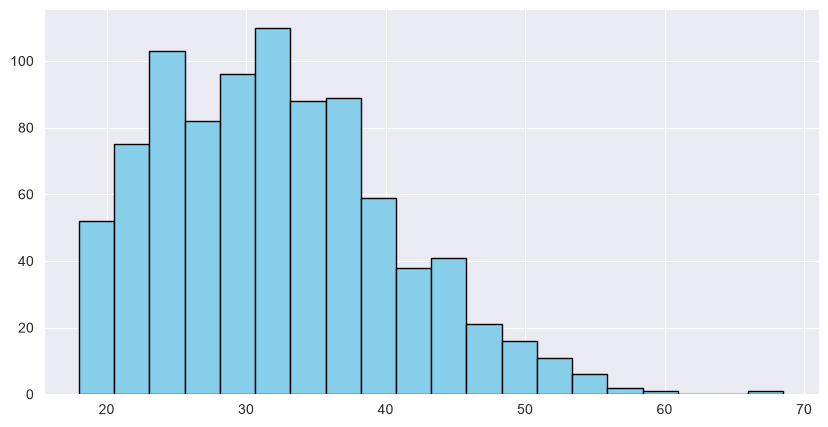

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Генерация синтетического набора данных возраста
np.random.seed(42)  # Зафиксируем seed для воспроизводимости результатов
n_users = 1000       # Количество пользователей
mean_age = 30        # Среднее значение возраста
std_dev = 10         # Стандартное отклонение

# Генерируем нормально распределённые данные с заданными параметрами
ages = np.random.normal(mean_age, std_dev, n_users)

# Ограничиваем диапазон возрастов от 18 до 70 лет
ages = ages[(ages >= 18) & (ages <= 70)]

# Преобразуем массив возрастов в DataFrame
data = pd.DataFrame({'age': ages})

# Ваш код здесь
data.info()
print(data)


plt.figure(figsize=(10, 5))
plt.hist(data['age'], bins=20, color='skyblue', edgecolor='black')
#plt.plot(data['age'])


plt.show()





Решение:

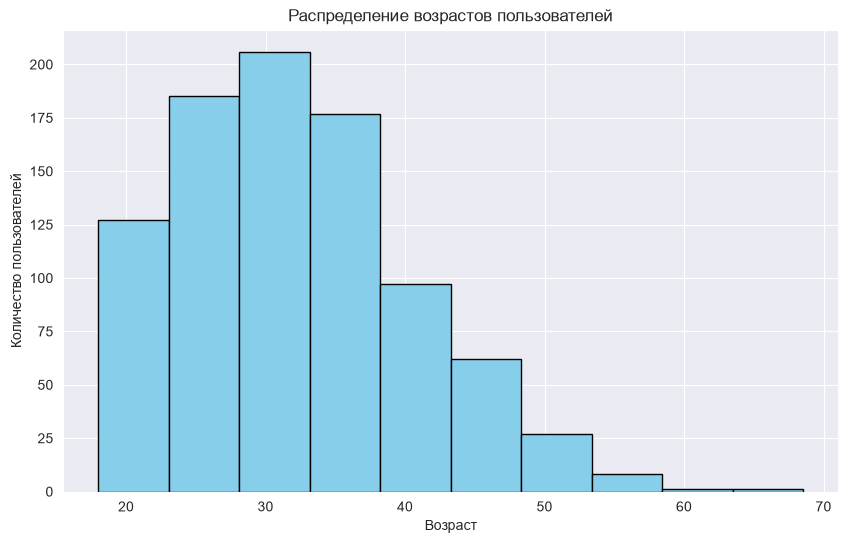

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Генерация синтетического набора данных возраста
np.random.seed(42)  # Зафиксируем seed для воспроизводимости результатов
n_users = 1000       # Количество пользователей
mean_age = 30        # Среднее значение возраста
std_dev = 10         # Стандартное отклонение

# Генерируем нормально распределённые данные с заданными параметрами
ages = np.random.normal(mean_age, std_dev, n_users)

# Ограничиваем диапазон возрастов от 18 до 70 лет
ages = ages[(ages >= 18) & (ages <= 70)]

# Преобразуем массив возрастов в DataFrame
data = pd.DataFrame({'age': ages})

# Строим гистограмму распределения возрастов
plt.figure(figsize=(10, 6))
plt.hist(data['age'], bins=10, color='skyblue', edgecolor='black')
plt.title('Распределение возрастов пользователей')
plt.xlabel('Возраст')
plt.ylabel('Количество пользователей')

# Сохраняем график в PNG-файл
plt.savefig('histogram.png')
plt.show()